# Project 1 - Regression
### Predict total bikes that will be rented per day
#### Group V
+ Ana Isabel Moura, 20250168
+ Ayoub Mask, 20250183
+ Beatriz Lobão, 20250566
+ Joao Bernardino, 20250922
+ Lara Pereira, 20250921

# Data Preparation - Linear Regression

In [1]:
#Load Packages

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#Optional:
try:
    from yellowbrick.model_selection import RFECV, LearningCurve
    from yellowbrick.regressor import ResidualsPlot, PredictionError
    YB_AVAILABLE = True
except ImportError:
    YB_AVAILABLE = False
    print('yellowbrick not available – skipping its visualisations.')

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')


In [2]:
# Loading the dataset 
ds = pd.read_excel('/Users/anamoura/Desktop/MachineLearning/Project_01/bike_day_v2.xlsx', engine='openpyxl')

In [3]:
# Summary statistics
ds.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
instant,732.0,366.352459,1.0,183.75,366.5,549.25,731.0,211.236679
dteday,732,2012-01-01 08:27:32.459016448,2011-01-01 00:00:00,2011-07-02 18:00:00,2012-01-01 12:00:00,2012-07-02 06:00:00,2012-12-31 00:00:00,NaN
season,732.0,2.497268,1.0,2.0,3.0,3.0,4.0,1.110203
yr,732.0,0.501366,0.0,0.0,1.0,1.0,1.0,0.50034
mnth,732.0,6.523224,1.0,4.0,7.0,10.0,12.0,3.450769
holiday,732.0,0.028689,0.0,0.0,0.0,0.0,1.0,0.167044
weekday,730.0,3.00274,0.0,1.0,3.0,5.0,6.0,2.004793
workingday,732.0,0.68306,0.0,0.0,1.0,1.0,1.0,0.465602
schoolday,454.0,0.460352,0.0,0.0,0.0,1.0,1.0,0.498975
weathersit,732.0,1.394809,1.0,1.0,1.0,2.0,3.0,0.544718


In [4]:
# Drop columns, identifier, and multicollinear atemp schoolday and workingday are dropped
cols_drop = ['instant', 'casual', 'registered', 'atemp', 'schoolday', 'workingday']
ds_prep = ds.drop(columns=cols_drop)

In [5]:
# Ensure dteday is datetime
ds_prep['dteday'] = pd.to_datetime(ds_prep['dteday'])
print(f'Shape after initial drops: {ds_prep.shape}')

Shape after initial drops: (732, 11)


In [6]:
# Fix missing weekday using calendar math (0=Sunday convention)
ds_prep['weekday'] = ds_prep['weekday'].fillna(
    ds_prep['dteday'].dt.dayofweek.apply(lambda x: (x + 1) % 7)
)
print(f'Missing values after imputation: {ds_prep[["weekday"]].isnull().sum().sum()}')

Missing values after imputation: 0


In [7]:
#Anomaly Correction 
# Windspeed: replace the 10.23 error with the closest valid neighbour (max ≤ 1.0)
closest_wind = ds_prep[ds_prep['windspeed'] <= 1.0]['windspeed'].max()
print(f'Top 5 valid windspeed values:\n{ds_prep[ds_prep["windspeed"] <= 1.0]["windspeed"].nlargest(5).values}')
print(f'Replacing outlier with: {closest_wind:.4f}')
ds_prep.loc[ds_prep['windspeed'] > 1.0, 'windspeed'] = closest_wind

# Humidity: replace 0.0 with the closest valid neighbour (min > 0)
closest_hum = ds_prep[ds_prep['hum'] > 0]['hum'].min()
print(f'Replacing humidity 0.0 with: {closest_hum:.4f}')
ds_prep.loc[ds_prep['hum'] == 0, 'hum'] = closest_hum


Top 5 valid windspeed values:
[0.507463 0.441563 0.422275 0.421642 0.417908]
Replacing outlier with: 0.5075
Replacing humidity 0.0 with: 0.1879


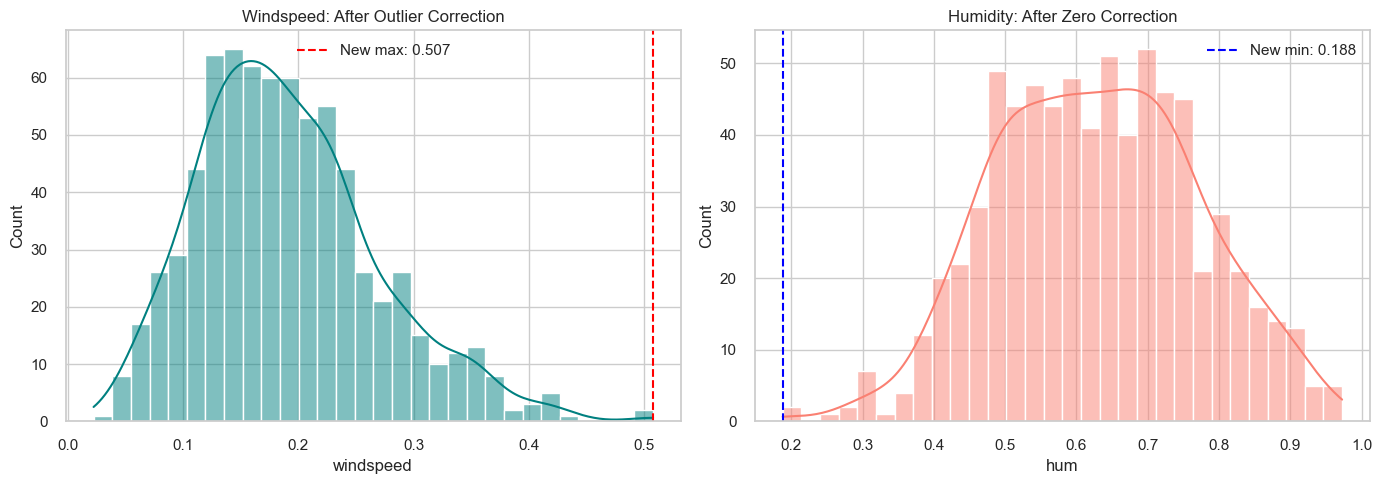

In [8]:
# Visualise corrections
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ds_prep['windspeed'], kde=True, ax=axes[0], color='teal', bins=30)
axes[0].axvline(closest_wind, color='red', linestyle='--', label=f'New max: {closest_wind:.3f}')
axes[0].set_title('Windspeed: After Outlier Correction')
axes[0].legend()

sns.histplot(ds_prep['hum'], kde=True, ax=axes[1], color='salmon', bins=30)
axes[1].axvline(closest_hum, color='blue', linestyle='--', label=f'New min: {closest_hum:.3f}')
axes[1].set_title('Humidity: After Zero Correction')
axes[1].legend()

plt.tight_layout()
plt.show()

### Feature Engineering

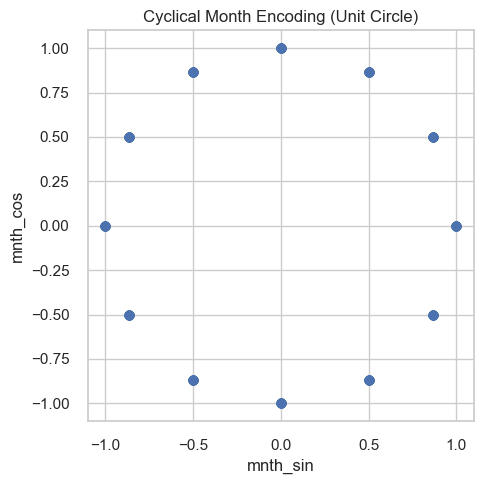

In [9]:
# Cyclical encoding for month
# Raw integers (1–12) create a false discontinuity: December (12) and January (1)

ds_prep['mnth_sin'] = np.sin(2 * np.pi * ds_prep['mnth'] / 12)
ds_prep['mnth_cos'] = np.cos(2 * np.pi * ds_prep['mnth'] / 12)
ds_prep.drop(columns=['mnth'], inplace=True)

# Check encoding
plt.figure(figsize=(5, 5))
plt.scatter(ds_prep['mnth_sin'], ds_prep['mnth_cos'], alpha=0.5)
plt.title('Cyclical Month Encoding (Unit Circle)')
plt.xlabel('mnth_sin')
plt.ylabel('mnth_cos')
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# Lag feature: yesterday's total rentals. At 15:00 we know how many bikes were rented today (the previous day for tomorrow's prediction)

ds_prep = ds_prep.sort_values('dteday').reset_index(drop=True)
ds_prep['cnt_lag1'] = ds_prep['cnt'].shift(1)
ds_prep.dropna(inplace=True)  # drop the first row which has no lag value
print(f'Shape after lag feature: {ds_prep.shape}')

Shape after lag feature: (731, 13)


### Encode Categorical Values 

In [11]:
#Encode season, weekday, weathersit

categorical_features = ['season', 'holiday', 'weekday', 'weathersit']
ds_final = pd.get_dummies(ds_prep, columns=categorical_features, drop_first=True)

# Sort by date and drop dteday — data is now in chronological order
ds_final = ds_final.sort_values('dteday').drop(columns=['dteday'])

print(f'Total features after encoding: {len(ds_final.columns)}')
print(ds_final.columns.tolist())

Total features after encoding: 20
['yr', 'temp', 'hum', 'windspeed', 'cnt', 'mnth_sin', 'mnth_cos', 'cnt_lag1', 'season_2', 'season_3', 'season_4', 'holiday_1', 'weekday_1.0', 'weekday_2.0', 'weekday_3.0', 'weekday_4.0', 'weekday_5.0', 'weekday_6.0', 'weathersit_2', 'weathersit_3']


### Feature Scaling (Min-Max)

 Min-Max scaling brings everything to the same 0–1 range, ensuring feature parity.


In [12]:
# Scale continuous numerical features
scaler = MinMaxScaler(feature_range=(0, 1))
cols_to_scale = ['temp', 'hum', 'windspeed', 'cnt_lag1']
ds_final[cols_to_scale] = scaler.fit_transform(ds_final[cols_to_scale])

# Convert any boolean dummy columns to int
ds_final = ds_final.astype(float)

print('Min-Max scaling applied. All features now in 0–1 range.')
ds_final[cols_to_scale].describe().T

Min-Max scaling applied. All features now in 0–1 range.


,count,mean,std,min,25%,50%,75%,max
temp,731.0,0.544045,0.228043,0.0,0.346343,0.549345,0.743002,1.0
hum,731.0,0.560576,0.180203,0.0,0.422730,0.558151,0.690653,1.0
windspeed,731.0,0.347125,0.160941,0.0,0.232045,0.326928,0.435276,1.0
cnt_lag1,731.0,0.516629,0.223463,0.0,0.362920,0.520824,0.685573,1.0


### Final Dataset Check

In [13]:
print(f'Final dataset shape: {ds_final.shape}')
print(f'Missing values: {ds_final.isnull().sum().sum()}')
ds_final.head(3)

Final dataset shape: (731, 20)
Missing values: 0


,yr,temp,hum,windspeed,cnt,mnth_sin,mnth_cos,cnt_lag1,season_2,season_3,season_4,holiday_1,weekday_1.0,weekday_2.0,weekday_3.0,weekday_4.0,weekday_5.0,weekday_6.0,weathersit_2,weathersit_3
1,0.0,0.379232,0.647694,0.466215,801.0,0.5,0.866025,0.110792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.171000,0.317820,0.465740,1349.0,0.5,0.866025,0.089623,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.175530,0.513034,0.284297,1562.0,0.5,0.866025,0.152669,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Define features (X) and target (y)
X = ds_final.drop(columns=['cnt'])
y = ds_final['cnt']

print(f'Features: {X.shape[1]} columns')
print(f'Target: {y.name}')

Features: 19 columns
Target: cnt


## Modeling 

The Split Strategies were: 
+ Chronological -  Train on past, test on future 
+ Random -  Shuffle rows randomly

### Chronological Split

In [15]:
# 80% - train | 20% - test
# Data is already sorted chronologically
train_size = int(len(ds_final) * 0.80)

train_chrono = ds_final.iloc[:train_size]
test_chrono  = ds_final.iloc[train_size:]

X_train_c = train_chrono.drop(columns=['cnt'])
y_train_c = train_chrono['cnt']
X_test_c  = test_chrono.drop(columns=['cnt'])
y_test_c  = test_chrono['cnt']

print(f'Chronological Split:')
print(f'  Train rows: {len(X_train_c)}')
print(f'  Test rows:  {len(X_test_c)}')

Chronological Split:
  Train rows: 584
  Test rows:  147


### Random Split 

In [16]:
# Random split
# 80% train, 20% test

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.20, random_state=2026
)
print(f'Random Split:')
print(f'  Train rows: {len(X_train_r)}')
print(f'  Test rows:  {len(X_test_r)}')

Random Split:
  Train rows: 584
  Test rows:  147


### Learning Curve - Chronological

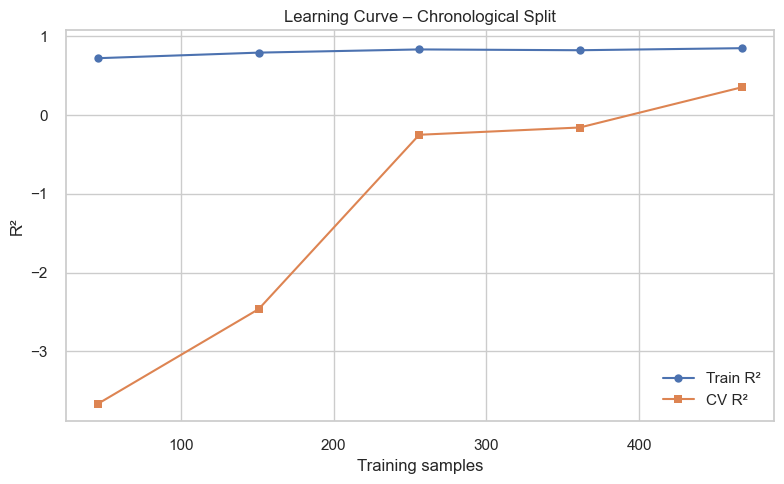

In [17]:
train_sizes_c, train_scores_c, val_scores_c = learning_curve(
    LinearRegression(), X_train_c, y_train_c, cv=5, scoring='r2'
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_c, np.mean(train_scores_c, axis=1), 'o-', label='Train R²')
plt.plot(train_sizes_c, np.mean(val_scores_c,   axis=1), 's-', label='CV R²')
plt.title('Learning Curve – Chronological Split')
plt.xlabel('Training samples')
plt.ylabel('R²')
plt.legend()
plt.tight_layout()
plt.show()

### Learning Curve - Random

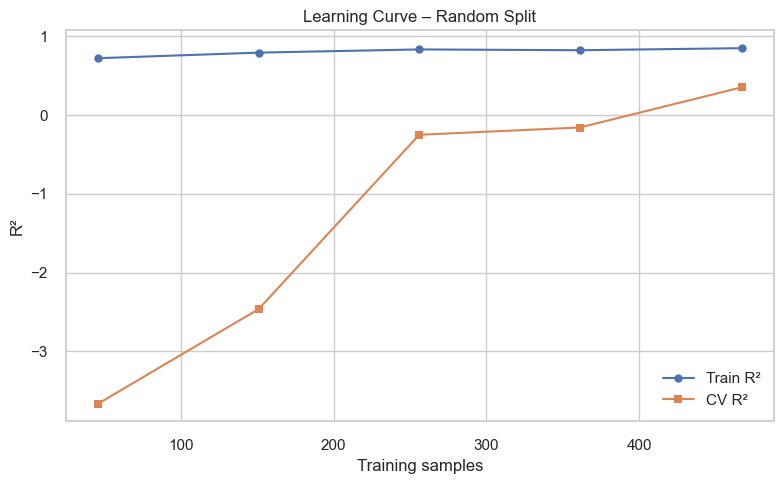

In [18]:
train_sizes_r, train_scores_r, val_scores_r = learning_curve(
    LinearRegression(), X_train_c, y_train_c, cv=5, scoring='r2'
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_r, np.mean(train_scores_r, axis=1), 'o-', label='Train R²')
plt.plot(train_sizes_r, np.mean(val_scores_r,   axis=1), 's-', label='CV R²')
plt.title('Learning Curve – Random Split')
plt.xlabel('Training samples')
plt.ylabel('R²')
plt.legend()
plt.tight_layout()
plt.show()

### Train Models

In [19]:
# Chronological model 
lr_chrono = LinearRegression()
lr_chrono.fit(X_train_c, y_train_c)

# Random model 
lr_random = LinearRegression()
lr_random.fit(X_train_r, y_train_r)

print('Both models trained')

Both models trained


### Coefficients (Key Drivers)

/var/folders/nl/gmgb358n27x2frmnd449xns80000gn/T/ipykernel_6866/29261157.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_c, x='Coefficient', y='Feature', palette='coolwarm', ax=ax)


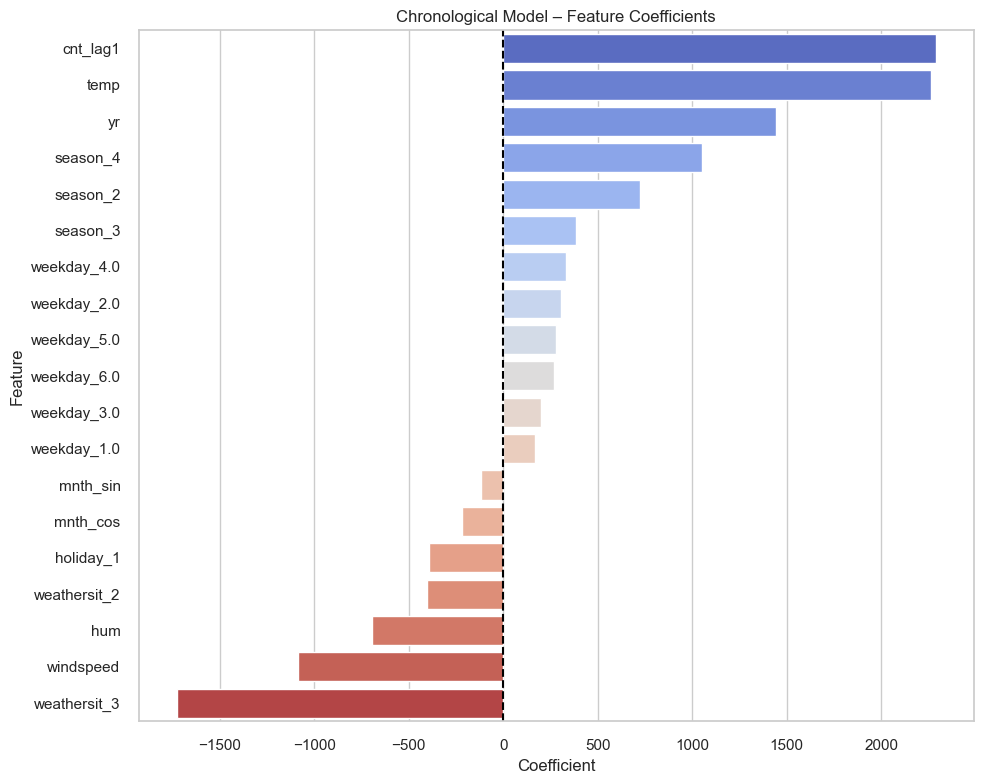

Top 5 drivers for INCREASING rentals:
    Feature  Coefficient
6  cnt_lag1  2290.102980
1      temp  2261.691398
0        yr  1442.349383
9  season_4  1053.263621
7  season_2   724.462808

Top 5 drivers for DECREASING rentals:
         Feature  Coefficient
10     holiday_1  -393.968923
17  weathersit_2  -403.420783
2            hum  -695.292039
3      windspeed -1085.134544
18  weathersit_3 -1727.753494


In [20]:
# Chronological model coefficients
coef_c = pd.DataFrame({
    'Feature': X_train_c.columns,
    'Coefficient': lr_chrono.coef_
}).sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=coef_c, x='Coefficient', y='Feature', palette='coolwarm', ax=ax)
ax.axvline(0, color='black', linestyle='--')
ax.set_title('Chronological Model – Feature Coefficients')
plt.tight_layout()
plt.show()

print('Top 5 drivers for INCREASING rentals:')
print(coef_c.head(5).to_string())
print('\nTop 5 drivers for DECREASING rentals:')
print(coef_c.tail(5).to_string())

/var/folders/nl/gmgb358n27x2frmnd449xns80000gn/T/ipykernel_6866/3094054250.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_r, x='Coefficient', y='Feature', palette='coolwarm', ax=ax)


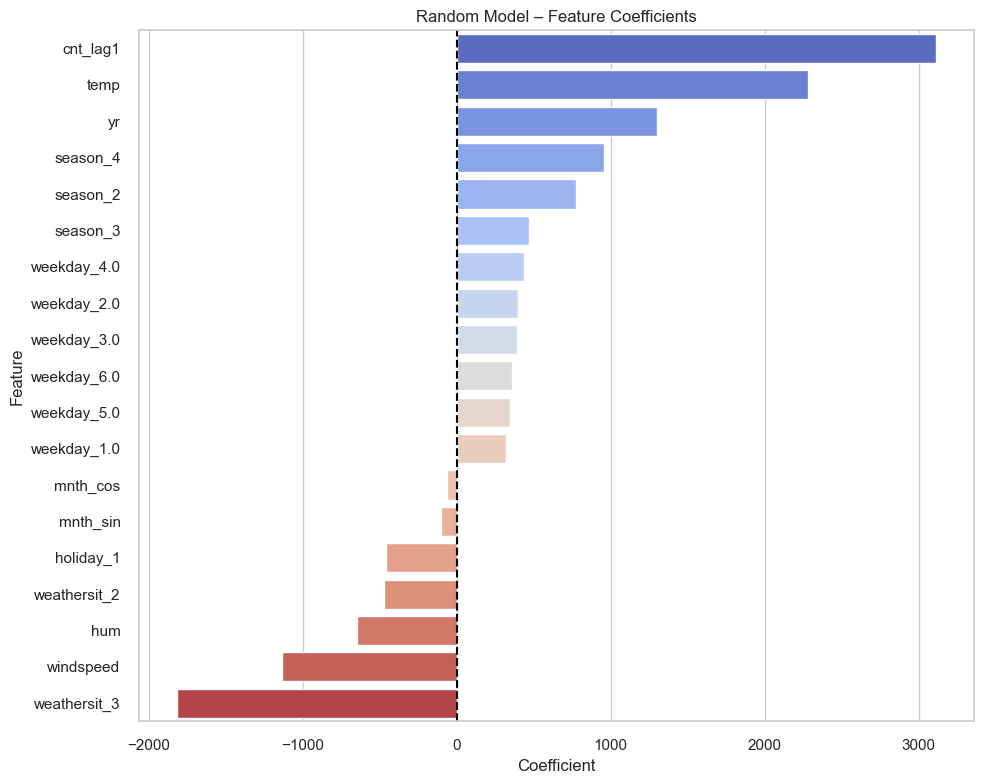

Top 5 drivers for INCREASING rentals:
    Feature  Coefficient
6  cnt_lag1  3112.571609
1      temp  2280.014564
0        yr  1302.297709
9  season_4   954.343431
7  season_2   774.598159

Top 5 drivers for DECREASING rentals:
         Feature  Coefficient
10     holiday_1  -463.033980
17  weathersit_2  -474.530414
2            hum  -649.621986
3      windspeed -1138.777033
18  weathersit_3 -1820.668631


In [21]:
# Random model coefficients
coef_r = pd.DataFrame({
    'Feature': X_train_r.columns,
    'Coefficient': lr_random.coef_
}).sort_values('Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=coef_r, x='Coefficient', y='Feature', palette='coolwarm', ax=ax)
ax.axvline(0, color='black', linestyle='--')
ax.set_title('Random Model – Feature Coefficients')
plt.tight_layout()
plt.show()

print('Top 5 drivers for INCREASING rentals:')
print(coef_r.head(5).to_string())
print('\nTop 5 drivers for DECREASING rentals:')
print(coef_r.tail(5).to_string())

## Evaluation

### Performance Metrics Function

In [22]:
def performanceMetricsDF(yTrain, yPredTrain, yTest, yPredTest):
    measures = ['MAE', 'RMSE', 'R²', 'MAPE (%)', 'Max Error']
    train_res = [
        metrics.mean_absolute_error(yTrain, yPredTrain),
        np.sqrt(metrics.mean_squared_error(yTrain, yPredTrain)),
        metrics.r2_score(yTrain, yPredTrain),
        metrics.mean_absolute_percentage_error(yTrain, yPredTrain) * 100,
        metrics.max_error(yTrain, yPredTrain)
    ]
    test_res = [
        metrics.mean_absolute_error(yTest, yPredTest),
        np.sqrt(metrics.mean_squared_error(yTest, yPredTest)),
        metrics.r2_score(yTest, yPredTest),
        metrics.mean_absolute_percentage_error(yTest, yPredTest) * 100,
        metrics.max_error(yTest, yPredTest)
    ]
    return pd.DataFrame({'Measure': measures, 'Train': train_res, 'Test': test_res})

### Chronological Split Results 

In [23]:
y_pred_train_c = lr_chrono.predict(X_train_c)
y_pred_test_c  = lr_chrono.predict(X_test_c)

print('Chronological Split Evaluation')
performanceMetricsDF(y_train_c, y_pred_train_c, y_test_c, y_pred_test_c)

Chronological Split Evaluation


,Measure,Train,Test
0,MAE,488.845428,747.354648
1,RMSE,670.172265,1008.861057
2,R²,0.859383,0.713714
3,MAPE (%),15.641862,121.918476
4,Max Error,3364.612606,3335.896896


In [24]:
# Overfitting check
tr_c = metrics.r2_score(y_train_c, y_pred_train_c)
te_c = metrics.r2_score(y_test_c,  y_pred_test_c)
gap_c = tr_c - te_c
print(f'Train R²: {tr_c:.4f}')
print(f'Test  R²: {te_c:.4f}')
print(f'Gap:      {gap_c:.4f}  ({"Overfit" if gap_c > 0.10 else "Ok"})')

Train R²: 0.8594
Test  R²: 0.7137
Gap:      0.1457  (Overfit)


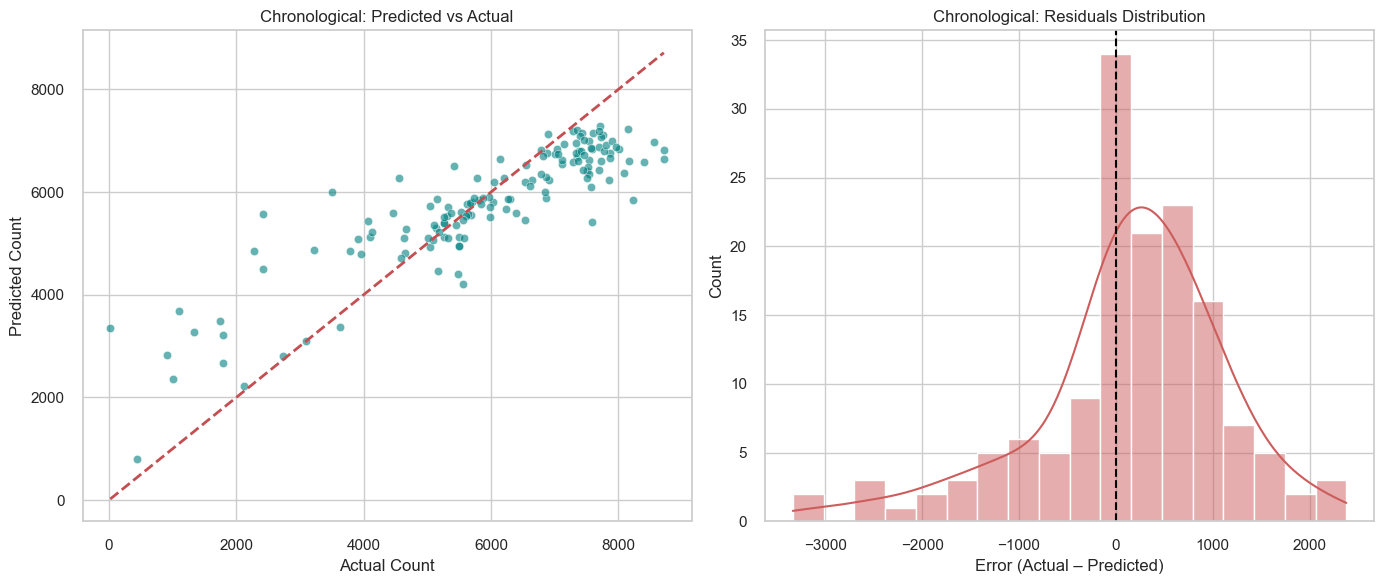

In [25]:
# Predicted vs Actual — Chronological
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=y_test_c, y=y_pred_test_c, alpha=0.6, color='teal', ax=axes[0])
axes[0].plot([y_test_c.min(), y_test_c.max()], [y_test_c.min(), y_test_c.max()], 'r--', lw=2)
axes[0].set_title('Chronological: Predicted vs Actual')
axes[0].set_xlabel('Actual Count')
axes[0].set_ylabel('Predicted Count')

# Residuals
residuals_c = y_test_c - y_pred_test_c
sns.histplot(residuals_c, kde=True, color='indianred', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Chronological: Residuals Distribution')
axes[1].set_xlabel('Error (Actual – Predicted)')

plt.tight_layout()
plt.show()

### Random Split Results

In [26]:
y_pred_train_r = lr_random.predict(X_train_r)
y_pred_test_r  = lr_random.predict(X_test_r)

print('Random Split Evaluation')
performanceMetricsDF(y_train_r, y_pred_train_r, y_test_r, y_pred_test_r)

Random Split Evaluation


,Measure,Train,Test
0,MAE,531.160018,522.489246
1,RMSE,728.460005,777.082082
2,R²,0.858307,0.840772
3,MAPE (%),16.470054,113.788829
4,Max Error,3445.060443,3230.902455


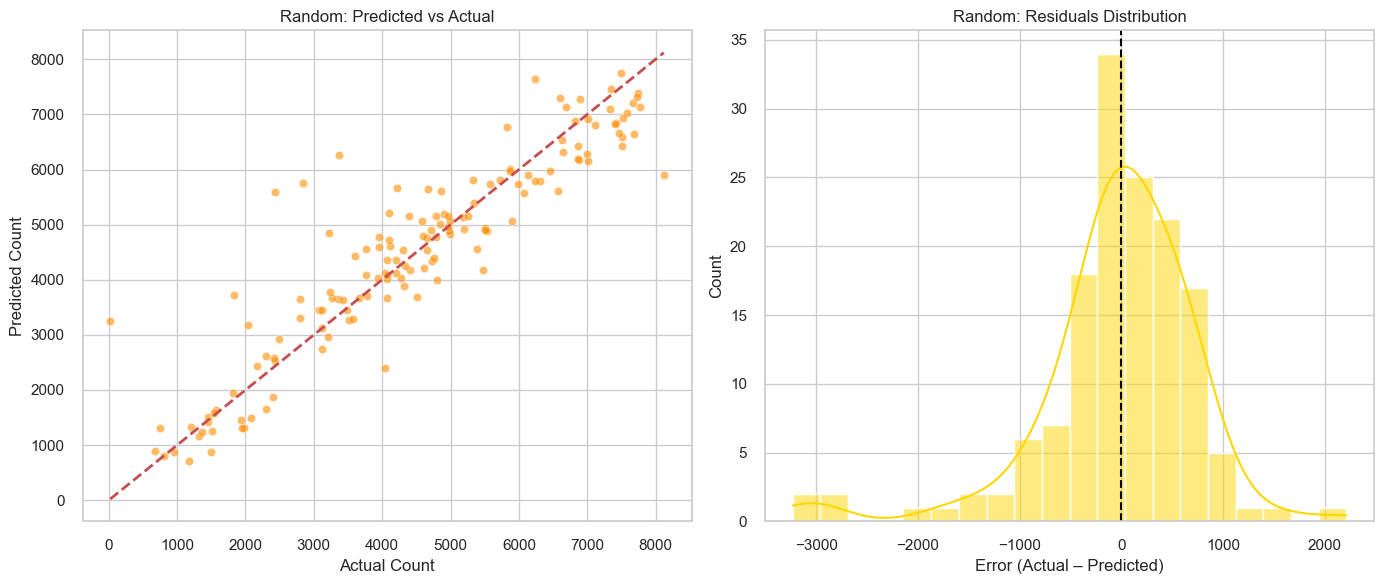

In [27]:
# Predicted vs Actual — Random
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=y_test_r, y=y_pred_test_r, alpha=0.6, color='darkorange', ax=axes[0])
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[0].set_title('Random: Predicted vs Actual')
axes[0].set_xlabel('Actual Count')
axes[0].set_ylabel('Predicted Count')

residuals_r = y_test_r - y_pred_test_r
sns.histplot(residuals_r, kde=True, color='gold', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Random: Residuals Distribution')
axes[1].set_xlabel('Error (Actual – Predicted)')

plt.tight_layout()
plt.show()

### Split Comparison 

In [28]:
comparison = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE', 'MAPE (%)'],
    'Chronological': [
        metrics.r2_score(y_test_c, y_pred_test_c),
        metrics.mean_absolute_error(y_test_c, y_pred_test_c),
        np.sqrt(metrics.mean_squared_error(y_test_c, y_pred_test_c)),
        metrics.mean_absolute_percentage_error(y_test_c, y_pred_test_c) * 100
    ],
    'Random': [
        metrics.r2_score(y_test_r, y_pred_test_r),
        metrics.mean_absolute_error(y_test_r, y_pred_test_r),
        np.sqrt(metrics.mean_squared_error(y_test_r, y_pred_test_r)),
        metrics.mean_absolute_percentage_error(y_test_r, y_pred_test_r) * 100
    ]
})
comparison

,Metric,Chronological,Random
0,R²,0.713714,0.840772
1,MAE,747.354648,522.489246
2,RMSE,1008.861057,777.082082
3,MAPE (%),121.918476,113.788829


Observations: 
The Random split tends to produce a slightly optimistic R2 because it can train on future data. The Chronological split is more realistic, it trains only on the past and predicts the future. 

### Simulation

In [29]:
# What the model would produce at 15:00 for the next day (chronological test)
simulation_c = pd.DataFrame({
    'Actual_Tomorrow':         y_test_c.values,
    'Predicted_at_15h_Today':  y_pred_test_c.round(0),
    'Error':                   (y_test_c.values - y_pred_test_c).round(0)
}).head(10)

print('Business Simulation – Sample predictions (Chronological Test):')
print(simulation_c.to_string())

Business Simulation – Sample predictions (Chronological Test):
   Actual_Tomorrow  Predicted_at_15h_Today  Error
0           7534.0                  6617.0  917.0
1           7286.0                  7181.0  105.0
2           5786.0                  6282.0 -496.0
3           6299.0                  5868.0  431.0
4           6544.0                  6526.0   18.0
5           6883.0                  6770.0  113.0
6           6784.0                  6818.0  -34.0
7           7347.0                  6685.0  662.0
8           7605.0                  7151.0  454.0
9           7148.0                  6935.0  213.0


In [30]:
# What the model would produce at 15:00 for the next day (random test)
simulation_r = pd.DataFrame({
    'Actual_Tomorrow':         y_test_r.values,
    'Predicted_at_15h_Today':  y_pred_test_r.round(0),
    'Error':                   (y_test_c.values - y_pred_test_r).round(0)
}).head(10)

print('Business Simulation – Sample predictions (Random Test):')
print(simulation_r.to_string())

Business Simulation – Sample predictions (Random Test):
   Actual_Tomorrow  Predicted_at_15h_Today   Error
0           6624.0                  6542.0   992.0
1           7504.0                  6593.0   693.0
2           7415.0                  6846.0 -1060.0
3           4511.0                  3679.0  2620.0
4           7582.0                  7028.0  -484.0
5           1450.0                  1422.0  5461.0
6           7525.0                  6936.0  -152.0
7           2298.0                  2608.0  4739.0
8           7665.0                  7205.0   400.0
9           5180.0                  5141.0  2007.0


## Deployment

### Business Criteria Check

In [31]:
# Using chronological split 
c_final_r2   = metrics.r2_score(y_test_c, y_pred_test_c)
c_final_mape = metrics.mean_absolute_percentage_error(y_test_c, y_pred_test_c) * 100
c_final_gap  = metrics.r2_score(y_train_c, y_pred_train_c) - c_final_r2

c_criteria = {
    'R² ≥ 0.75':               (c_final_r2   >= 0.75, f'{c_final_r2:.4f}'),
    'MAPE ≤ 20%':              (c_final_mape <= 20.0,  f'{c_final_mape:.2f}%'),
    'Gap < 0.10 (no overfit)': (c_final_gap  <  0.10,  f'{c_final_gap:.4f}'),
}

print('Business Success Criteria')
print('-' * 50)
for criterion, (passed, value) in criteria.items():
    status = 'Pass' if passed else 'FAIL'
    print(f'{status}  |  {criterion}  -  {value}')

Business Success Criteria
--------------------------------------------------


NameError: name 'criteria' is not defined

In [ ]:
# Using random split 
r_final_r2   = metrics.r2_score(y_test_r, y_pred_test_r)
r_final_mape = metrics.mean_absolute_percentage_error(y_test_r, y_pred_test_r) * 100
r_final_gap  = metrics.r2_score(y_train_r, y_pred_train_r) - r_final_r2

r_criteria = {
    'R² ≥ 0.75':               (r_final_r2   >= 0.75, f'{r_final_r2:.4f}'),
    'MAPE ≤ 20%':              (r_final_mape <= 20.0,  f'{r_final_mape:.2f}%'),
    'Gap < 0.10 (no overfit)': (r_final_gap  <  0.10,  f'{r_final_gap:.4f}'),
}

print('Business Success Criteria')
print('-' * 50)
for criterion, (passed, value) in r_criteria.items():
    status = 'Pass' if passed else 'FAIL'
    print(f'{status}  |  {criterion}  -  {value}')

## Conclusions

### Key findings
- Temperature is the strongest positive driver of daily rentals. Both splits agree on this consistently. 
- Year shows significant growth from 2011 to 2012, confirming the business is expanding. 
- Weather has a clear negative effect: higher weathersit values (rain, snow) reduce demand. 
- Month cyclical encoding improved the model's ability to handle seasonal transitions. 
- Lag feature (`cnt_lag1`), yesterday's demand, is a strong predictor, as demand tends to be autocorrelated. 

### Chronological vs Random Split
- Random split produces slightly higher R² but is optimistic, it trains on future data. 
- Chronological split is the realistic estimate, it mirrors actual rentals use. 
- The chronological split result is what we should report to the business stakeholder. 

### Limitations
- Only 2 years of data (2011–2012), seasonal patterns may evolve and changes over time. 
- Linear Regression assumes linear relationships — interactions between temperature and humidity are not captured unless explicitly engineered. 
- MAPE may be elevated on low-demand days (holidays, bad weather). 
